# Predictive Maintenance Using Linear Regression

## Project Overview

This project extends the Data Stream Visualization Workshop by adding
machine learning-based anomaly detection.

Historical robot current measurements are retrieved from a Neon
PostgreSQL database and used to train Linear Regression models for
Axes #1–#8.

The models estimate the expected current for each robot axis.
Differences between actual and predicted current are analyzed to
identify unusual behaviour.

Sustained abnormal deviations are classified as Alerts or Errors to
simulate a predictive maintenance system.

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("../..")

from src.data_service.database_manager import Database
from src.data_service.datacollection import StreamingSimulator

from src.ml.regression_model import RegressionModel
from src.ml.threshold_analyzer import ThresholdAnalyzer

## 2. Retrieve Training Data From Neon

The historical robot measurements are retrieved directly from the
Neon PostgreSQL database.

This database data will be used as the training dataset for the
Linear Regression models.

In [2]:
db = Database()

training_df = db.fetch_all()

db.connection.close()

print("Training records:", len(training_df))

display(training_df.head())

c:\Users\aarya\Desktop\Streaming Data for Predictive Maintenance with Linear Regression-Based Alerts\src\anomalies\../..\src\data_service\database_manager.py:161: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(


Training records: 39672


,id,trait,axis_1,axis_2,axis_3,axis_4,axis_5,axis_6,axis_7,axis_8,axis_9,axis_10,axis_11,axis_12,axis_13,axis_14,time
0,69713,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,2022-10-17T12:18:23.660Z
1,69714,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,2022-10-17T12:18:25.472Z
2,69715,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,2022-10-17T12:18:27.348Z
3,69716,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,2022-10-17T12:18:29.222Z
4,69717,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,2022-10-17T12:18:31.117Z


## 3. Select Robot Axes

The assignment requires separate Linear Regression models for
robot Axes #1 through #8.

These eight current measurements are selected from the training data.

In [3]:
axis_columns = [
    "axis_1",
    "axis_2",
    "axis_3",
    "axis_4",
    "axis_5",
    "axis_6",
    "axis_7",
    "axis_8"
]

display(
    training_df[
        ["time"] + axis_columns
    ].head()
)

,time,axis_1,axis_2,axis_3,axis_4,axis_5,axis_6,axis_7,axis_8
0,2022-10-17T12:18:23.660Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2022-10-17T12:18:25.472Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2022-10-17T12:18:27.348Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2022-10-17T12:18:29.222Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2022-10-17T12:18:31.117Z,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4. Prepare Axis Measurements

The robot measurements stored in PostgreSQL are converted to numeric
values so they can be used by the Linear Regression models.

In [4]:
for axis in axis_columns:

    training_df[axis] = pd.to_numeric(
        training_df[axis],
        errors="coerce"
    )

In [5]:
print(
    training_df[axis_columns]
    .isnull()
    .sum()
)

axis_1    0
axis_2    0
axis_3    0
axis_4    0
axis_5    0
axis_6    0
axis_7    0
axis_8    0
dtype: int64


## 5. Convert Time to Elapsed Seconds

Linear Regression requires numerical input.

The timestamp is converted into the number of seconds elapsed since
the first measurement. Elapsed time will be used as the independent
variable for each regression model.

In [6]:
training_df["time"] = pd.to_datetime(
    training_df["time"],
    errors="coerce"
)

start_time = training_df["time"].min()

training_df["elapsed_seconds"] = (
    training_df["time"] - start_time
).dt.total_seconds()

In [7]:
display(
    training_df[
        ["time", "elapsed_seconds"] + axis_columns
    ].head()
)

,time,elapsed_seconds,axis_1,axis_2,axis_3,axis_4,axis_5,axis_6,axis_7,axis_8
0,2022-10-17 12:18:23.660000+00:00,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2022-10-17 12:18:25.472000+00:00,1.812,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2022-10-17 12:18:27.348000+00:00,3.688,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2022-10-17 12:18:29.222000+00:00,5.562,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2022-10-17 12:18:31.117000+00:00,7.457,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 6. Train Linear Regression Models

A separate Linear Regression model is trained for each robot axis.

For every model:

- Input (X) = elapsed time
- Output (y) = axis current

The slope and intercept describe the regression line for each axis.

In [8]:
from src.ml.regression_model import RegressionModel

In [9]:
regression = RegressionModel(axis_columns)

model_information = regression.train(training_df)

model_summary = pd.DataFrame(
    model_information
).T

display(model_summary)

,slope,intercept
axis_1,-1.176729e-07,0.730542
axis_2,2.194203e-06,3.523886
axis_3,-5.777186e-07,2.733898
axis_4,3.890034e-07,0.604357
axis_5,8.381178e-08,0.951103
axis_6,4.744455e-07,0.580077
axis_7,5.537186e-07,0.847563
axis_8,8.499989e-08,0.098748


## 7. Generate Regression Predictions

The trained models are used to calculate the expected current for
each robot axis.

These predicted values represent the baseline behaviour learned from
the historical training data.

In [10]:
training_results = regression.predict(
    training_df
)

display(
    training_results[
        [
            "elapsed_seconds",
            "axis_1",
            "axis_1_predicted"
        ]
    ].head()
)

,elapsed_seconds,axis_1,axis_1_predicted
0,0.000,0.0,0.730542
1,1.812,0.0,0.730542
2,3.688,0.0,0.730542
3,5.562,0.0,0.730541
4,7.457,0.0,0.730541


## 8. Calculate Residuals

A residual is the difference between the actual current and the
current predicted by the regression model.

Residual = Actual Current - Predicted Current

A positive residual means that the actual current is higher than
expected. Large positive residuals may indicate abnormal robot
behaviour.

In [11]:
training_results = regression.calculate_residuals(
    training_df
)

In [12]:
display(
    training_results[
        [
            "axis_1",
            "axis_1_predicted",
            "axis_1_residual"
        ]
    ].head()
)

,axis_1,axis_1_predicted,axis_1_residual
0,0.0,0.730542,-0.730542
1,0.0,0.730542,-0.730542
2,0.0,0.730542,-0.730542
3,0.0,0.730541,-0.730541
4,0.0,0.730541,-0.730541


## 9. Visualize Regression Models

The following plots compare the actual robot current measurements
with the regression line learned by each model.

The regression line represents the expected current behaviour over
time.

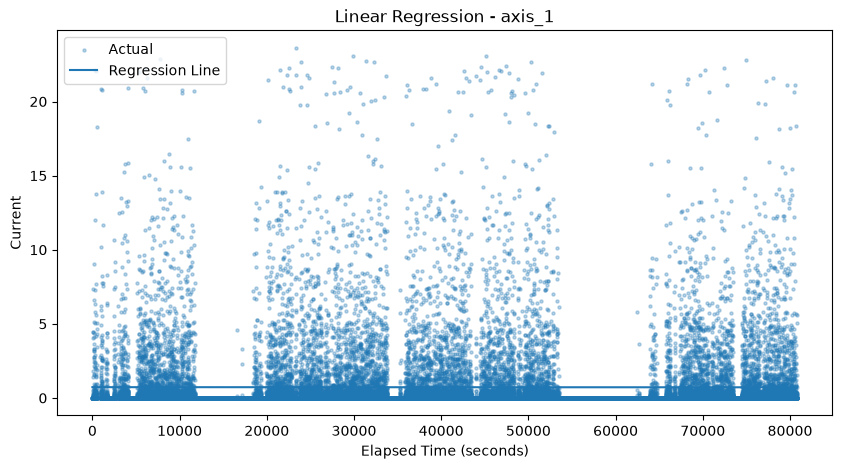

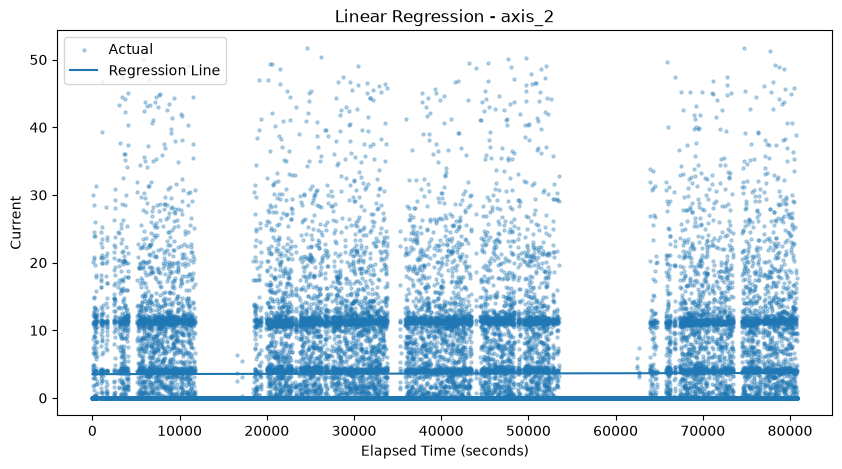

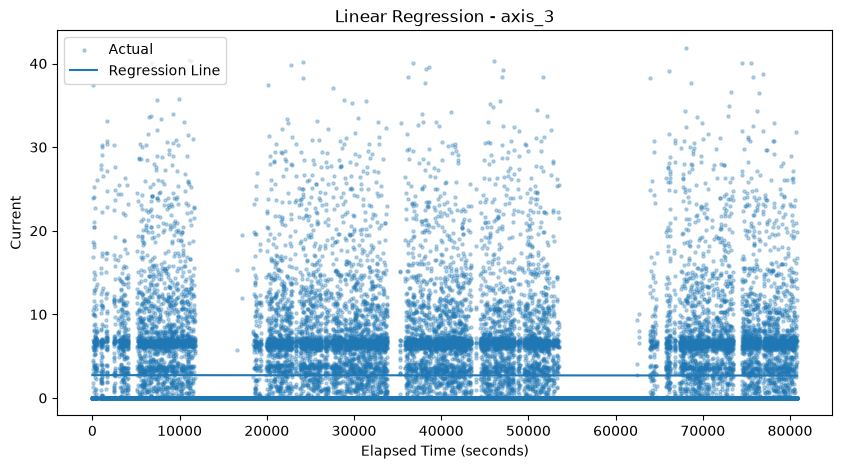

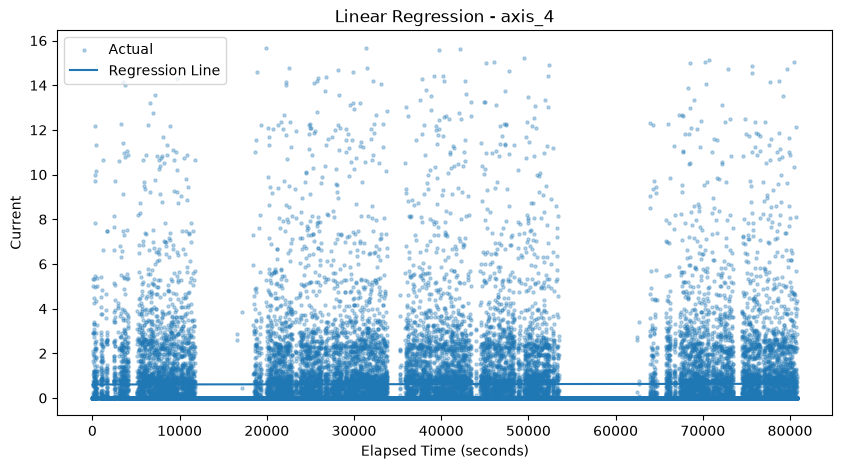

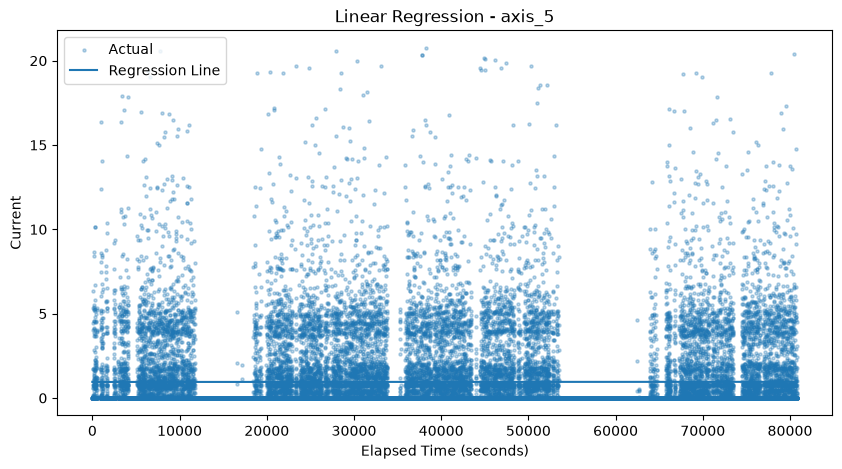

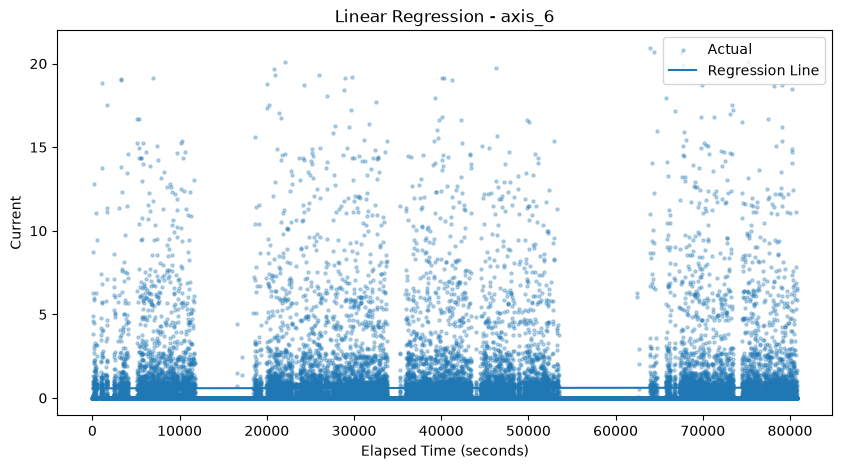

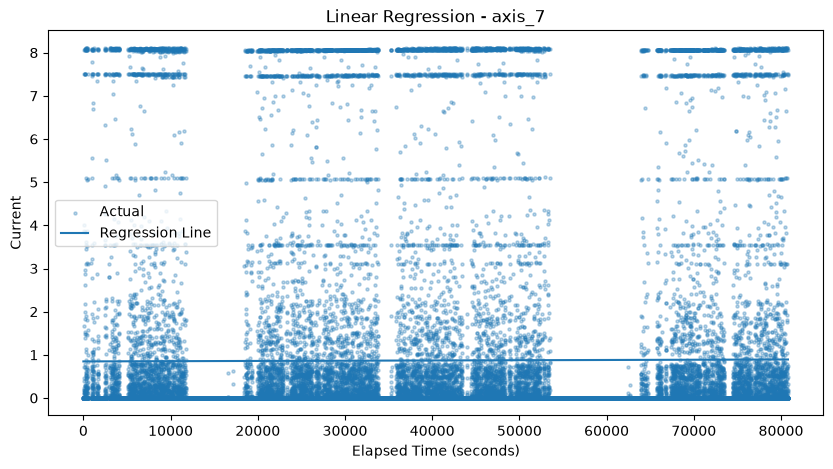

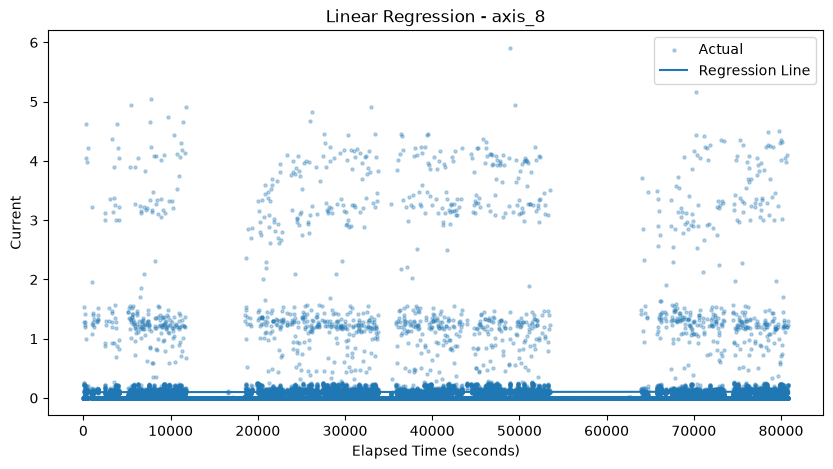

In [13]:
for axis in axis_columns:

    plt.figure(figsize=(10, 5))

    plt.scatter(
        training_results["elapsed_seconds"],
        training_results[axis],
        s=5,
        alpha=0.3,
        label="Actual"
    )

    plt.plot(
        training_results["elapsed_seconds"],
        training_results[f"{axis}_predicted"],
        label="Regression Line"
    )

    plt.title(
        f"Linear Regression - {axis}"
    )

    plt.xlabel("Elapsed Time (seconds)")
    plt.ylabel("Current")

    plt.legend()

    plt.show()

## 10. Residual Analysis

Residuals are analyzed to determine how far normal robot measurements
usually deviate from the regression prediction.

The distribution of residuals will be used to discover suitable
thresholds for Alerts and Errors instead of selecting arbitrary
values.

In [14]:
from src.ml.threshold_analyzer import ThresholdAnalyzer

threshold_analyzer = ThresholdAnalyzer(
    axis_columns
)

residual_df = (
    threshold_analyzer
    .calculate_residual_summary(
        training_results
    )
)

display(residual_df)

,axis,mean,std,95th_percentile,99th_percentile,max
0,axis_1,-5.731339e-17,2.162118,3.622423,10.637570,22.881511
1,axis_2,2.980296e-16,6.879775,13.548942,27.827261,48.082660
2,axis_3,3.668057e-16,5.111883,9.756149,22.004903,39.160990
3,axis_4,6.304473e-17,1.574871,2.506291,7.724843,15.054179
4,axis_5,-8.023874e-17,2.100185,4.106583,8.931155,19.796448
5,axis_6,-1.203581e-16,1.815465,2.498980,9.737241,20.320990
6,axis_7,-1.719402e-16,2.166773,7.175265,7.227199,7.260771
7,axis_8,0.000000e+00,0.423071,0.096614,2.866628,5.802731


## 11. Visualize Residual Distributions

Residual distributions are plotted to identify typical deviations
and unusually large positive values.

Values in the extreme upper portion of the distributions may
represent abnormal current behaviour.

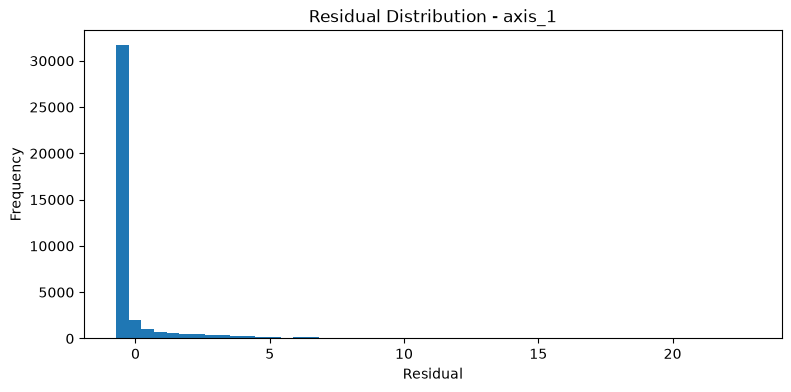

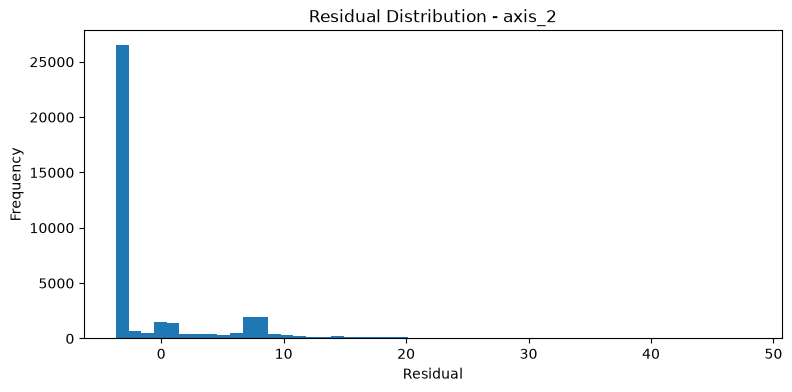

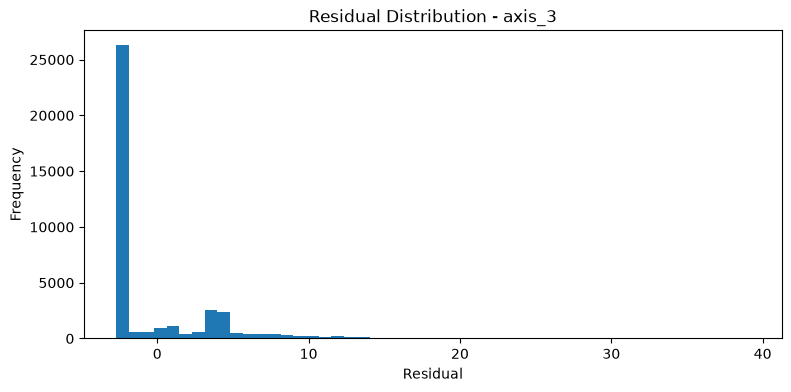

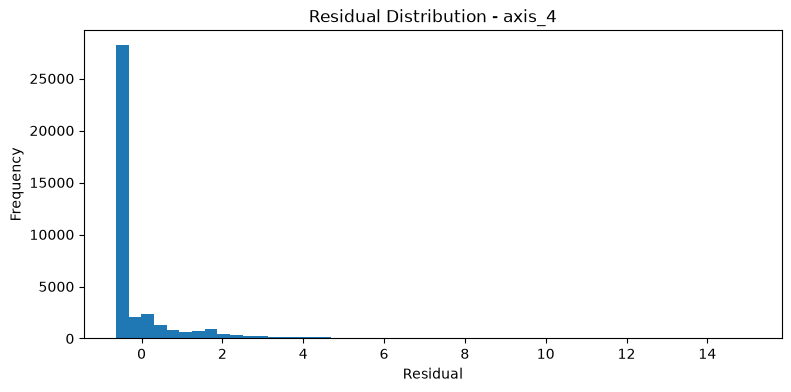

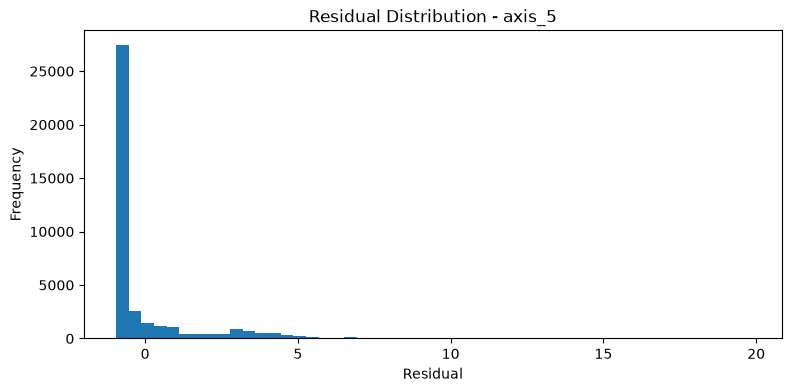

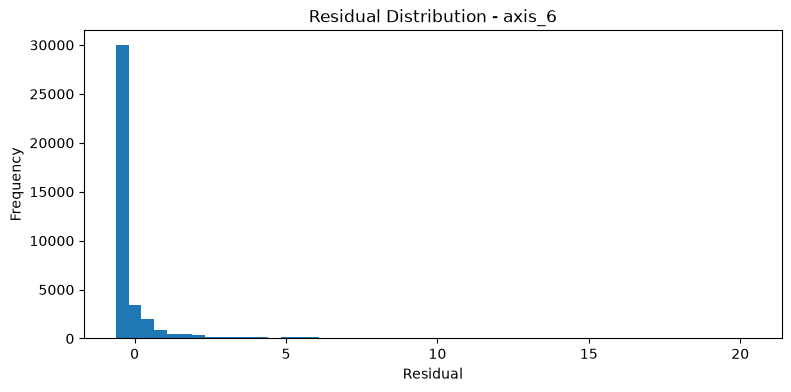

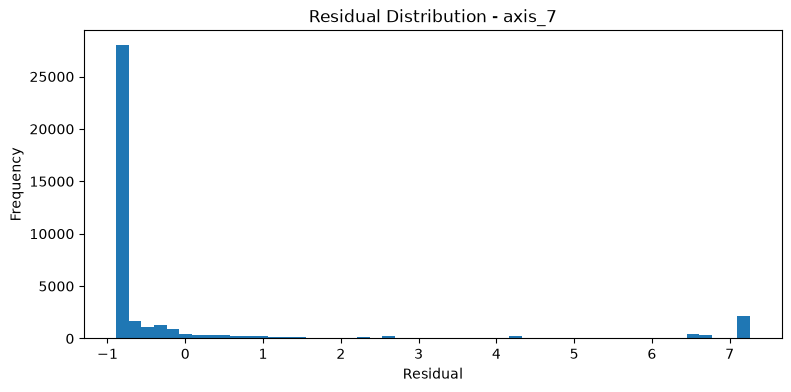

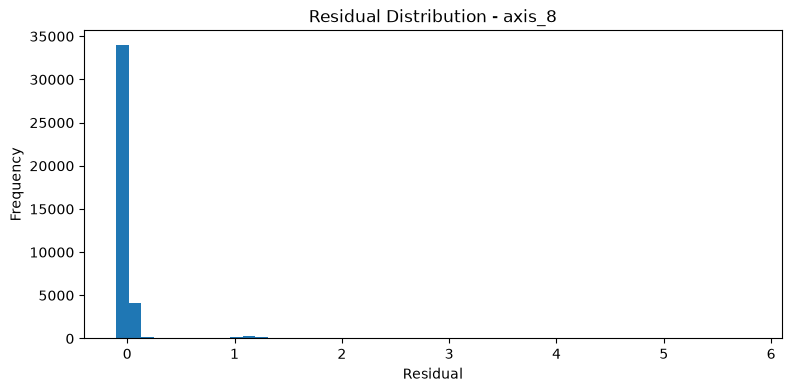

In [15]:
for axis in axis_columns:

    plt.figure(figsize=(9, 4))

    plt.hist(
        training_results[
            f"{axis}_residual"
        ].dropna(),
        bins=50
    )

    plt.title(
        f"Residual Distribution - {axis}"
    )

    plt.xlabel("Residual")
    plt.ylabel("Frequency")

    plt.show()

## 12. Discover MinC and MaxC Thresholds

The residual analysis shows that the eight robot axes have different
current ranges and different levels of variation. Therefore, using one
fixed current threshold for every axis would not accurately represent
their normal behaviour.

For this project, separate thresholds are calculated for each axis:

- **MinC (Alert threshold): 95th percentile of positive residual behaviour**
- **MaxC (Error threshold): 99th percentile of positive residual behaviour**

The 95th percentile represents an unusually high deviation from the
regression prediction, while the 99th percentile represents a more
extreme deviation.

These thresholds are calculated from the historical training data
retrieved from Neon PostgreSQL rather than selecting arbitrary fixed
values.

In [16]:
thresholds = (
    threshold_analyzer
    .calculate_thresholds(
        training_results
    )
)

threshold_df = pd.DataFrame(
    thresholds
).T

display(threshold_df)

,MinC,MaxC
axis_1,3.622423,10.637570
axis_2,13.548942,27.827261
axis_3,9.756149,22.004903
axis_4,2.506291,7.724843
axis_5,4.106583,8.931155
axis_6,2.498980,9.737241
axis_7,7.175265,7.227199
axis_8,0.096614,2.866628


## 13. Select the Duration Threshold (T)

An Alert or Error should not be generated because of only one unusual
measurement. The deviation must continue for a minimum amount of time.

The timestamp analysis showed that the normal median interval between
measurements is approximately **1.89 seconds**.

The median is preferred because the dataset contains a large time gap
of more than 400 seconds, which would affect the mean.

This project requires approximately three consecutive abnormal
measurements before generating an event:

**1.89 × 3 ≈ 5.67 seconds**

Therefore, the duration threshold is rounded to:

**T = 6 seconds**

This reduces the chance of generating an Alert or Error from a single
temporary spike.

### Threshold Justification

Separate thresholds are calculated for each robot axis because the
residual distributions and current variations are different across
Axes #1–#8. Using one global threshold would not represent the normal
behaviour of every axis fairly.

**MinC (Alert Threshold)** is selected using the 95th percentile of the
training residuals. A positive residual above this level represents a
larger-than-normal increase in current compared with the regression
prediction.

**MaxC (Error Threshold)** is selected using the 99th percentile of the
training residuals. This represents a more extreme positive deviation
and is therefore treated as a more severe Error condition.

The thresholds are calculated from the historical training data
retrieved from Neon PostgreSQL rather than manually assigning fixed
current values.

In [17]:
sampling_interval = (
    threshold_analyzer
    .calculate_sampling_interval(
        training_df
    )
)

T = 6

print(
    "Median sampling interval:",
    round(sampling_interval, 3),
    "seconds"
)

print(
    "Duration threshold (T):",
    T,
    "seconds"
)

Median sampling interval: 1.891 seconds
Duration threshold (T): 6 seconds


### Duration Threshold Justification

The median sampling interval of the historical robot data is
approximately **1.891 seconds**.

A duration threshold of **T = 6 seconds** was selected so that an
unusual residual must persist across multiple consecutive measurements
before an Alert or Error is generated.

This prevents a single temporary current spike from immediately being
classified as a maintenance event.

The controlled test events use five consecutive abnormal measurements.
From the first measurement to the fifth measurement there are four
sampling intervals:

**4 × 1.891 ≈ 7.56 seconds**

Therefore, the controlled abnormal conditions persist longer than the
selected **6-second** duration threshold and can be detected by the
system.

## 14. Generate Synthetic Testing Data

The Linear Regression models were trained using historical robot data
retrieved from Neon PostgreSQL.

A separate synthetic dataset is now created for testing. The synthetic
data is generated using information learned from the training dataset,
including the mean and standard deviation of each robot axis.

The generated values follow the regression trend with additional random
variation. This creates new testing observations while maintaining
similar characteristics to the historical robot data.

The testing data remains separate from the training data so that the
trained models can be evaluated on new simulated robot measurements.

In [18]:
from src.ml.synthetic_data_generator import SyntheticDataGenerator

In [19]:
generator = SyntheticDataGenerator(
    axis_columns
)

training_statistics = (
    generator.learn_statistics(
        training_df
    )
)

generator.fit_scaler(
    training_df
)

print(
    "Training statistics learned successfully."
)

Training statistics learned successfully.


### Training Data Statistics

The mean and standard deviation of each robot axis are calculated from
the Neon training data.

These statistics are used when generating the synthetic testing data.

In [20]:
statistics_df = pd.DataFrame({
    "mean": training_statistics["mean"],
    "std": training_statistics["std"]
})

display(statistics_df)

,mean,std
axis_1,0.725743,2.162120
axis_2,3.613374,6.879962
axis_3,2.710336,5.111901
axis_4,0.620222,1.574897
axis_5,0.954521,2.100186
axis_6,0.599427,1.815498
axis_7,0.870145,2.166811
axis_8,0.102214,0.423075


### Generate Synthetic Data

In [21]:
synthetic_df = generator.generate(
    regression_models=regression.models,
    number_of_rows=500,
    sampling_interval=sampling_interval
)

print(
    "Synthetic testing records:",
    len(synthetic_df)
)

display(
    synthetic_df.head()
)

Synthetic testing records: 500


,elapsed_seconds,axis_1,axis_2,axis_3,axis_4,axis_5,axis_6,axis_7,axis_8
0,0.000,1.389377,12.907206,2.430851,-0.287499,0.001922,1.584187,3.553958,-0.004283
1,1.891,-1.518028,9.682728,-0.994146,-0.379328,-0.447364,1.031980,2.337662,0.658111
2,3.782,2.353107,-1.426102,0.615150,2.691327,1.862604,2.411314,5.107791,0.367758
3,5.673,2.764155,-6.813268,5.974382,1.124532,1.480044,1.459604,-2.506295,-0.404916
4,7.564,-3.487831,-16.871943,2.749195,0.270901,-1.999220,2.790858,0.272582,0.167086


### Compare Training and Synthetic Data Statistics

The following comparison checks whether the generated synthetic testing
data has statistical characteristics similar to the historical training
data retrieved from Neon PostgreSQL.

The mean and standard deviation of each robot axis are compared between
the training and synthetic datasets.

In [22]:
comparison_data = []

for axis in axis_columns:

    comparison_data.append({
        "axis": axis,
        "training_mean": training_df[axis].mean(),
        "synthetic_mean": synthetic_df[axis].mean(),
        "training_std": training_df[axis].std(),
        "synthetic_std": synthetic_df[axis].std()
    })


statistics_comparison = pd.DataFrame(
    comparison_data
)

display(statistics_comparison)

,axis,training_mean,synthetic_mean,training_std,synthetic_std
0,axis_1,0.725743,0.702106,2.162120,2.075492
1,axis_2,3.613374,3.217683,6.879962,7.006414
2,axis_3,2.710336,2.713571,5.111901,5.220808
3,axis_4,0.620222,0.354394,1.574897,1.579272
4,axis_5,0.954521,0.948829,2.100186,2.142287
5,axis_6,0.599427,0.704670,1.815498,1.839399
6,axis_7,0.870145,0.889137,2.166811,2.094165
7,axis_8,0.102214,0.089487,0.423075,0.417430


### Synthetic Data Validation

The generated synthetic testing data was compared with the historical
training data retrieved from Neon PostgreSQL.

The synthetic means and standard deviations are close to the
corresponding training statistics across the eight robot axes. This
shows that the generated testing data preserves similar statistical
characteristics while remaining separate from the historical training
dataset.

The synthetic measurements are generated around the expected Linear
Regression trend, with random variation based on the standard deviation
learned from the training data. A fixed random state is used so that the
experiment can be reproduced.

## 15. Standardize Synthetic Testing Data

Standardization converts the robot axis values into Z-scores.

The StandardScaler is fitted using only the historical training data
retrieved from Neon PostgreSQL. The same fitted scaler is then applied
to the synthetic testing data.

This prevents information from the testing dataset from being used to
fit the preprocessing step.

A Z-score describes how many standard deviations a value is from the
training mean.

In [23]:
standardized_df = generator.standardize(
    synthetic_df
)

display(
    standardized_df.head()
)

,elapsed_seconds,axis_1,axis_2,axis_3,axis_4,axis_5,axis_6,axis_7,axis_8,axis_1_zscore,axis_2_zscore,axis_3_zscore,axis_4_zscore,axis_5_zscore,axis_6_zscore,axis_7_zscore,axis_8_zscore
0,0.000,1.389377,12.907206,2.430851,-0.287499,0.001922,1.584187,3.553958,-0.004283,0.306941,1.350872,-0.054674,-0.576376,-0.453584,0.542426,1.238616,-0.251725
1,1.891,-1.518028,9.682728,-0.994146,-0.379328,-0.447364,1.031980,2.337662,0.658111,-1.037778,0.882190,-0.724687,-0.634685,-0.667514,0.238259,0.677279,1.313959
2,3.782,2.353107,-1.426102,0.615150,2.691327,1.862604,2.411314,5.107791,0.367758,0.752680,-0.732495,-0.409869,1.315091,0.432388,0.998024,1.955731,0.627658
3,5.673,2.764155,-6.813268,5.974382,1.124532,1.480044,1.459604,-2.506295,-0.404916,0.942796,-1.515528,0.638527,0.320222,0.250230,0.473803,-1.558273,-1.198692
4,7.564,-3.487831,-16.871943,2.749195,0.270901,-1.999220,2.790858,0.272582,0.167086,-1.948841,-2.977571,0.007602,-0.221808,-1.406437,1.207084,-0.275784,0.153334


### Why Original Values Are Used for Regression

The synthetic testing data is standardized using a scaler fitted only
on the historical training data retrieved from Neon PostgreSQL. This
ensures that the testing data is standardized relative to the training
distribution rather than being fitted independently.

The standardized values are used to verify the preprocessing of the
synthetic testing data. However, the Linear Regression models continue
to use the original current values because the models were trained using
the original current units.

The MinC and MaxC thresholds were also calculated from residuals in the
original current units. Therefore, using the original values for
prediction and anomaly detection keeps the regression predictions,
residuals, and thresholds on the same scale.

##### Verifying standardization

In [24]:
zscore_columns = [
    f"{axis}_zscore"
    for axis in axis_columns
]

display(
    standardized_df[
        zscore_columns
    ].describe()
)

,axis_1_zscore,axis_2_zscore,axis_3_zscore,axis_4_zscore,axis_5_zscore,axis_6_zscore,axis_7_zscore,axis_8_zscore
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,-0.010932,-0.057514,0.000633,-0.168793,-0.002710,0.057970,0.008765,-0.030084
std,0.959946,1.018393,1.021317,1.002791,1.020059,1.013178,0.966485,0.986670
min,-2.564501,-3.661195,-2.951140,-3.057551,-3.065425,-2.872110,-2.759764,-2.633258
25%,-0.664718,-0.738103,-0.657689,-0.799750,-0.696708,-0.647153,-0.658723,-0.745187
50%,0.005393,-0.004068,0.007647,-0.145648,0.035041,0.024310,0.029930,-0.069055
75%,0.589607,0.583193,0.659998,0.498532,0.657351,0.780212,0.693772,0.616237
max,2.916105,3.166095,2.813839,2.904262,2.855851,3.049091,3.078276,2.837224


## 16. Inject Controlled Abnormal Behaviour

Controlled abnormal periods are added to the synthetic testing dataset
to verify that the Alert and Error detection rules work correctly.

Two test scenarios are created:

1. Axis 1 receives a sustained deviation above its Alert threshold.
2. Axis 2 receives a larger sustained deviation above its Error threshold.

Each abnormal period contains five consecutive measurements. Since the
median sampling interval is approximately 1.89 seconds, the time from
the first to the fifth measurement is approximately 7.56 seconds.

This exceeds the selected duration threshold of T = 6 seconds.

These controlled anomalies are added only to the synthetic testing data
and do not modify the historical training data.

##### Create Alert Test

In [25]:
axis_1_min_c = thresholds[
    "axis_1"
]["MinC"]

synthetic_df = generator.inject_anomaly(
    data=synthetic_df,
    regression_models=regression.models,
    axis="axis_1",
    start_row=100,
    duration_rows=5,
    threshold=axis_1_min_c,
    multiplier=1.5
)

##### Create Error Test

In [26]:
axis_2_max_c = thresholds[
    "axis_2"
]["MaxC"]

synthetic_df = generator.inject_anomaly(
    data=synthetic_df,
    regression_models=regression.models,
    axis="axis_2",
    start_row=250,
    duration_rows=5,
    threshold=axis_2_max_c,
    multiplier=1.5
)

### Re-standardize After Anomaly Injection

In [27]:
standardized_df = (
    generator.standardize(
        synthetic_df
    )
)

## 17. Save Synthetic Testing Dataset

The completed synthetic testing dataset is saved as a CSV file.

This file will be used by the existing StreamingSimulator class to
simulate a time-based stream of new robot measurements.

In [28]:
synthetic_df.to_csv(
    "../../data/synthetic_test_data.csv",
    index=False
)

print(
    "Synthetic testing dataset saved successfully."
)

Synthetic testing dataset saved successfully.


### Verify Synthetic Data

In [29]:
synthetic_check = pd.read_csv(
    "../../data/synthetic_test_data.csv"
)

print(
    "Rows:",
    len(synthetic_check)
)

display(
    synthetic_check.head()
)

Rows: 500


,elapsed_seconds,axis_1,axis_2,axis_3,axis_4,axis_5,axis_6,axis_7,axis_8
0,0.000,1.389377,12.907206,2.430851,-0.287499,0.001922,1.584187,3.553958,-0.004283
1,1.891,-1.518028,9.682728,-0.994146,-0.379328,-0.447364,1.031980,2.337662,0.658111
2,3.782,2.353107,-1.426102,0.615150,2.691327,1.862604,2.411314,5.107791,0.367758
3,5.673,2.764155,-6.813268,5.974382,1.124532,1.480044,1.459604,-2.506295,-0.404916
4,7.564,-3.487831,-16.871943,2.749195,0.270901,-1.999220,2.790858,0.272582,0.167086


## 18. Predict Synthetic Testing Data

The previously trained Linear Regression models are now applied to the
synthetic testing dataset.

For each robot axis, the model calculates the expected current and the
residual between the observed synthetic value and the regression
prediction.

The residuals are then used by the anomaly detector.

In [30]:
test_results = (
    regression.calculate_residuals(
        synthetic_df
    )
)

display(
    test_results[
        [
            "elapsed_seconds",
            "axis_1",
            "axis_1_predicted",
            "axis_1_residual"
        ]
    ].head()
)

,elapsed_seconds,axis_1,axis_1_predicted,axis_1_residual
0,0.000,1.389377,0.730542,0.658835
1,1.891,-1.518028,0.730542,-2.248570
2,3.782,2.353107,0.730542,1.622565
3,5.673,2.764155,0.730541,2.033614
4,7.564,-3.487831,0.730541,-4.218372


## 19. Detect Alerts and Errors

The AnomalyDetector evaluates each synthetic measurement using the
residual thresholds discovered from the historical training data.

An **Alert** occurs when the residual remains at or above MinC for at
least 6 continuous seconds.

An **Error** occurs when the residual remains at or above MaxC for at
least 6 continuous seconds.

The detector processes the testing observations sequentially to
simulate real-time predictive maintenance monitoring.

In [31]:
from src.ml.anomaly_detector import AnomalyDetector


detector = AnomalyDetector(
    axis_columns=axis_columns,
    thresholds=thresholds,
    duration_threshold=T
)

In [32]:
for _, row in test_results.iterrows():

    elapsed_seconds = row[
        "elapsed_seconds"
    ]

    for axis in axis_columns:

        residual = row[
            f"{axis}_residual"
        ]

        detector.check_reading(
            elapsed_seconds,
            axis,
            residual
        )

In [33]:
events_df = (
    detector.get_event_log()
)

print(
    "Total detected events:",
    len(events_df)
)

display(events_df)

Total detected events: 6


,axis,event_type,start_time,detected_time,duration_seconds,residual
0,axis_8,ALERT,128.588,136.152,7.564,0.153688
1,axis_1,ALERT,189.100,196.664,7.564,5.433635
2,axis_8,ALERT,283.650,291.214,7.564,0.263699
3,axis_8,ALERT,425.475,433.039,7.564,0.104502
4,axis_2,ERROR,472.750,480.314,7.564,41.740891
5,axis_8,ALERT,501.115,508.679,7.564,0.317486


### Analysis of Detected Events

The detector identified the two controlled maintenance events introduced
into the synthetic testing data:

- **Axis 1 - Alert:** A controlled deviation was introduced above the
  MinC threshold.
- **Axis 2 - Error:** A controlled deviation was introduced above the
  MaxC threshold.

The detector also identified additional Alert events on **Axis 8**.
These events were not manually injected. They occurred naturally in
the synthetic testing data because the generated measurements use
variation learned from the historical training data.

Axis 8 has a relatively small Alert threshold compared with its normal
variation. As a result, multiple consecutive synthetic measurements can
naturally remain above MinC long enough to satisfy the 6-second duration
requirement.

This demonstrates an important predictive-maintenance consideration:
a statistically derived threshold may still require validation and
adjustment to balance anomaly sensitivity against false-alert frequency.

In [46]:
controlled_events = events_df[
    (
        (events_df["axis"] == "axis_1")
        & (events_df["event_type"] == "ALERT")
    )
    |
    (
        (events_df["axis"] == "axis_2")
        & (events_df["event_type"] == "ERROR")
    )
]

print(
    "Controlled events successfully detected:",
    len(controlled_events)
)

display(controlled_events)

Controlled events successfully detected: 2


,axis,event_type,start_time,detected_time,duration_seconds,residual
1,axis_1,ALERT,189.10,196.664,7.564,5.433635
4,axis_2,ERROR,472.75,480.314,7.564,41.740891


### Threshold Validation

The testing results show that the percentile-based thresholds successfully
detected both controlled maintenance scenarios. Axis 1 detected the
injected Alert and Axis 2 detected the injected Error.

However, additional Alert events were detected on Axis 8 even though no
controlled anomaly was injected into that axis. This indicates that the
95th-percentile MinC threshold for Axis 8 is relatively sensitive when
applied to synthetic data with variation similar to the historical
training data.

The threshold is not manually changed in this experiment because the
purpose is to evaluate the thresholds derived from the training
residuals rather than tune them specifically to produce a desired test
result.

In a production predictive-maintenance system, the threshold could be
validated using additional normal operating data and adjusted based on
the observed false-alert rate. Other approaches, such as a higher
percentile, a longer duration threshold, or axis-specific duration
requirements, could also be evaluated.

## 20. Log Predictive Maintenance Events

Detected Alert and Error events are stored in a structured CSV file.

The event log records the affected robot axis, event type, start time,
detection time, duration and residual value. This provides a record of
abnormal behaviour detected by the predictive maintenance system.

In [34]:
events_df.to_csv(
    "../../data/anomaly_events.csv",
    index=False
)

print(
    "Event log saved successfully."
)

Event log saved successfully.


## 21. Simulate Synthetic Testing Data

The existing StreamingSimulator class is reused to simulate incoming
robot measurements from the synthetic testing dataset.

The simulator reads the synthetic CSV sequentially so that each call
to `nextDataPoint()` represents a new measurement entering the
predictive maintenance pipeline.

The following demonstration displays the first 10 measurements from
the simulated stream.

In [35]:
ss = StreamingSimulator(
    "../../data/synthetic_test_data.csv"
)

for i in range(10):

    data_point = ss.nextDataPoint()

    if data_point is None:
        break

    print(data_point)

   elapsed_seconds    axis_1     axis_2    axis_3    axis_4    axis_5  \
0              0.0  1.389377  12.907206  2.430851 -0.287499  0.001922   

     axis_6    axis_7    axis_8  
0  1.584187  3.553958 -0.004283  
   elapsed_seconds    axis_1    axis_2    axis_3    axis_4    axis_5   axis_6  \
1            1.891 -1.518028  9.682728 -0.994146 -0.379328 -0.447364  1.03198   

     axis_7    axis_8  
1  2.337662  0.658111  
   elapsed_seconds    axis_1    axis_2   axis_3    axis_4    axis_5    axis_6  \
2            3.782  2.353107 -1.426102  0.61515  2.691327  1.862604  2.411314   

     axis_7    axis_8  
2  5.107791  0.367758  
   elapsed_seconds    axis_1    axis_2    axis_3    axis_4    axis_5  \
3            5.673  2.764155 -6.813268  5.974382  1.124532  1.480044   

     axis_6    axis_7    axis_8  
3  1.459604 -2.506295 -0.404916  
   elapsed_seconds    axis_1     axis_2    axis_3    axis_4   axis_5  \
4            7.564 -3.487831 -16.871943  2.749195  0.270901 -1.99922   

     

## 22. Store Synthetic Stream in Neon

A separate PostgreSQL table is used for the synthetic testing stream.

The historical `robot_data` table remains the source of training data,
while `synthetic_stream_data` stores the new simulated testing
measurements.

Keeping training and testing data separate prevents the synthetic test
records from modifying the historical training dataset.

In [36]:
db = Database()

db.create_synthetic_stream_table()

print(
    "Synthetic streaming table is ready."
)

db.connection.close()

Synthetic streaming table is ready.


In [51]:
db = Database()

db.clear_synthetic_data()

print(
    "Previous synthetic stream records cleared."
)

db.connection.close()

Previous synthetic stream records cleared.


## 23. Stream Synthetic Data to Neon

The StreamingSimulator reads the synthetic testing CSV sequentially.

Each simulated measurement is inserted into the
`synthetic_stream_data` table in Neon PostgreSQL. This represents the
CSV-to-database streaming flow used by the predictive maintenance
application.

The demonstration does not use a real-time delay so that the complete
notebook can run efficiently. The original elapsed time values are
preserved in the synthetic dataset.

In [52]:
ss = StreamingSimulator(
    "../../data/synthetic_test_data.csv"
)

db = Database()

streamed_records = 0

while True:

    data_point = ss.nextDataPoint()

    if data_point is None:
        break

    db.insert_synthetic_data(
        data_point
    )

    streamed_records += 1


db.connection.close()

print(
    "Records streamed to Neon:",
    streamed_records
)

Records streamed to Neon: 500


### Verify Streaming Results

The number of records stored in Neon is checked to confirm that the
complete synthetic testing stream was successfully inserted into the
database.

In [53]:
db = Database()

stream_count = db.count_synthetic_data()

db.connection.close()

print(
    "Synthetic records stored in Neon:",
    stream_count
)

Synthetic records stored in Neon: 500


## 24. Visualize Predictive Maintenance Results

The final plots combine the synthetic testing measurements with the
predictions produced by the trained Linear Regression models.

Alert and Error events detected by the anomaly detection system are
marked on the plots. Each event is also annotated with its duration.

These visualizations show when the actual robot current moves
significantly above its expected regression value for a sustained
period of time.

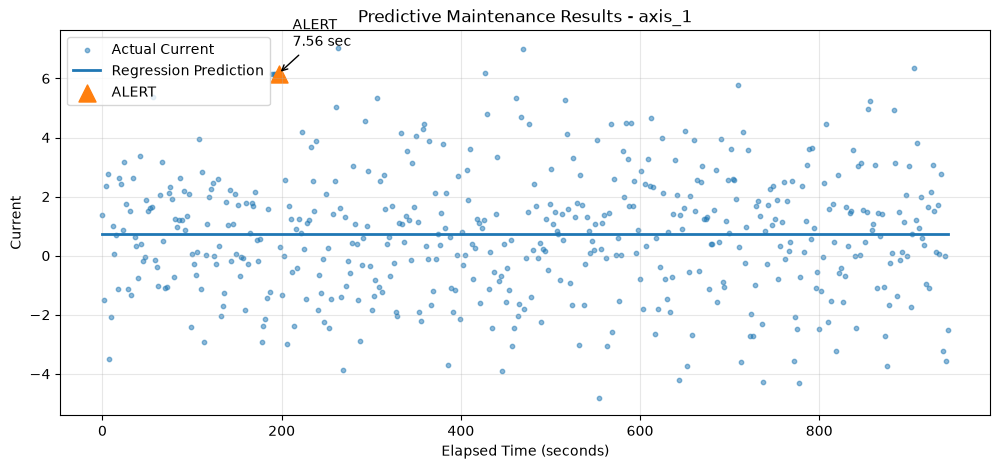

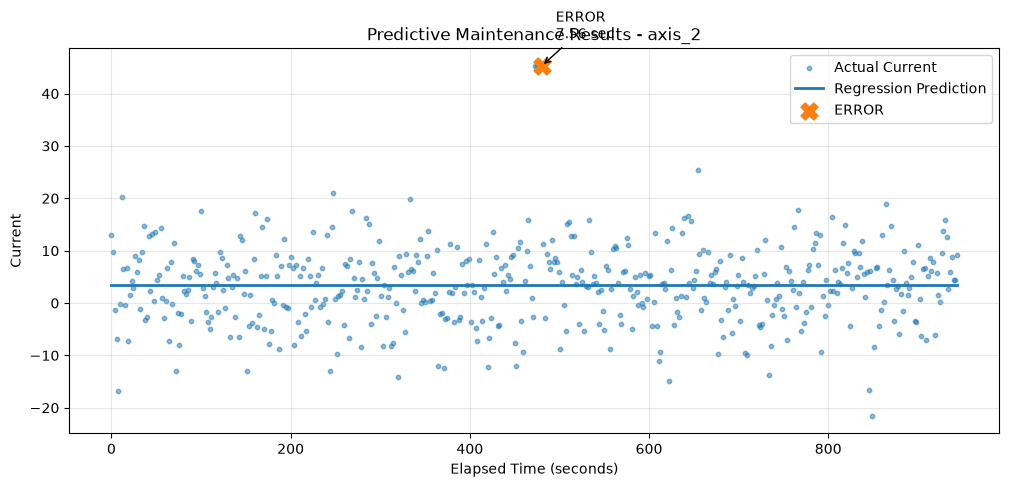

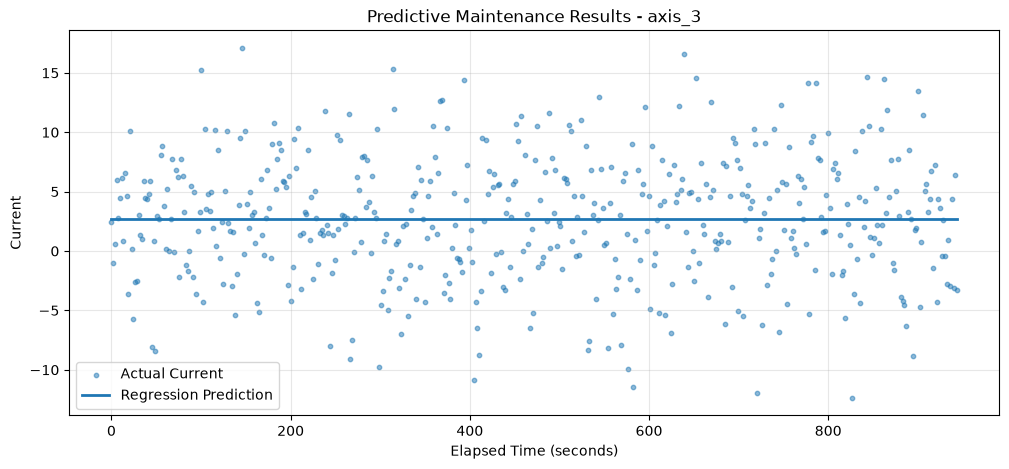

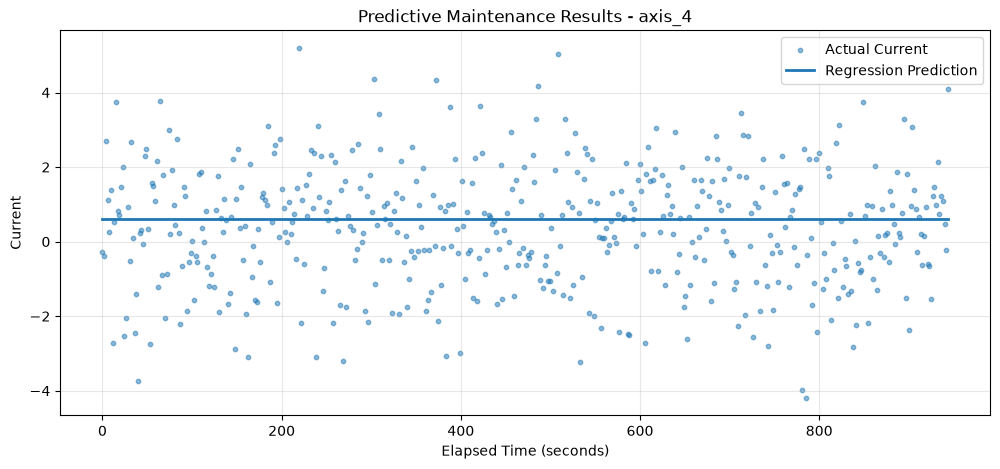

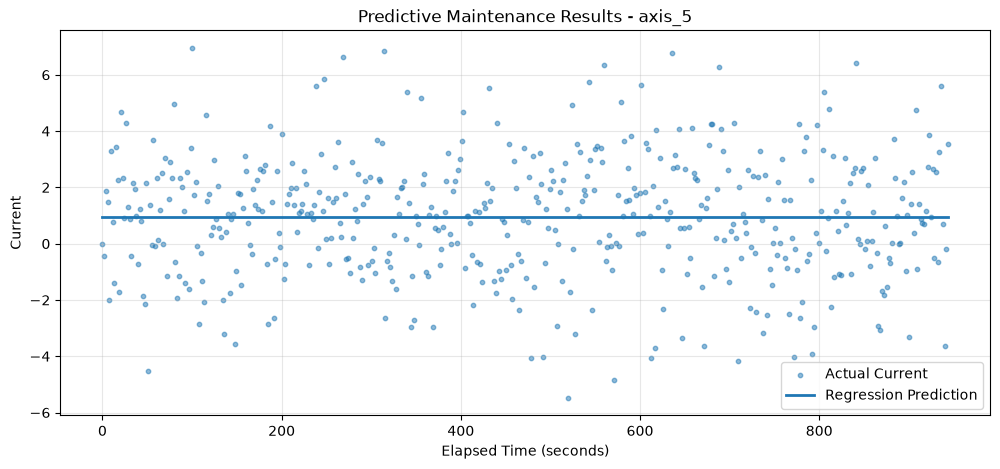

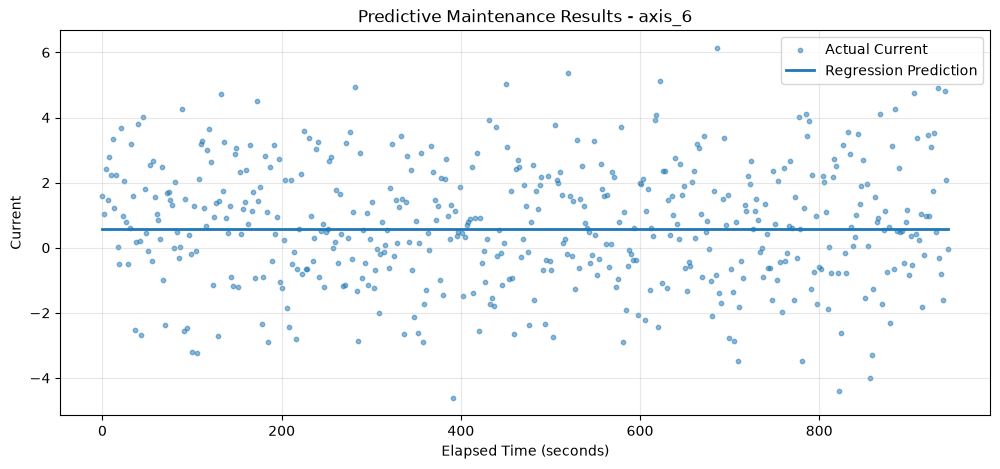

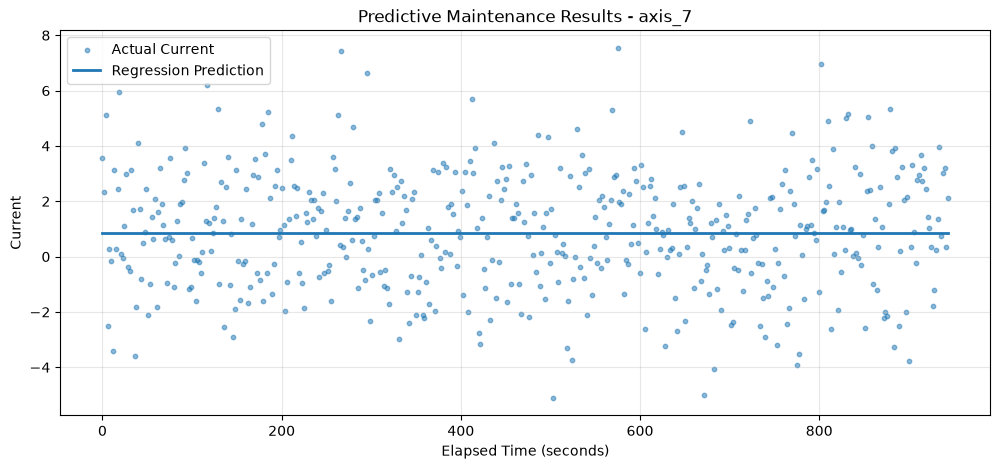

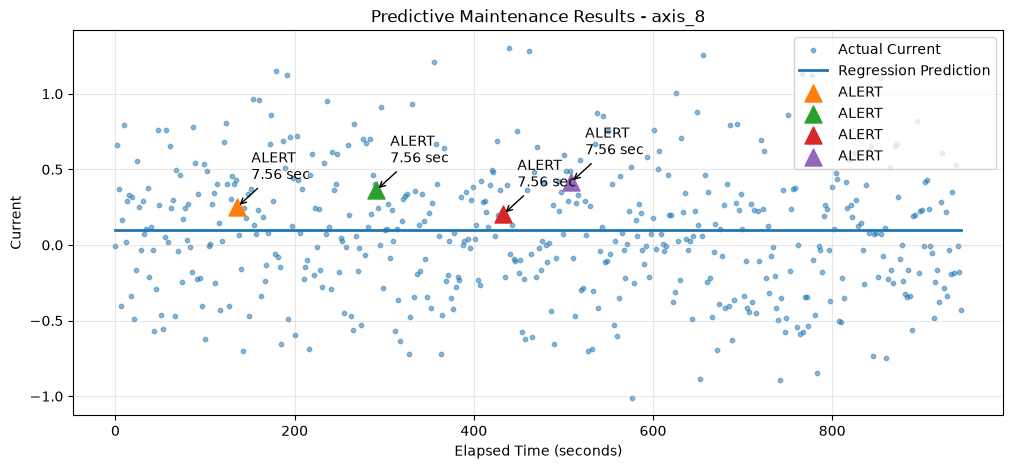

In [47]:
for axis in axis_columns:

    plt.figure(figsize=(12, 5))

    # Actual synthetic measurements
    plt.scatter(
        test_results["elapsed_seconds"],
        test_results[axis],
        s=10,
        alpha=0.5,
        label="Actual Current"
    )

    # Regression prediction
    plt.plot(
        test_results["elapsed_seconds"],
        test_results[f"{axis}_predicted"],
        linewidth=2,
        label="Regression Prediction"
    )

    # Get detected events for this axis
    axis_events = events_df[
        events_df["axis"] == axis
    ]

    for _, event in axis_events.iterrows():

        event_time = event["detected_time"]

        # Find the closest measurement
        closest_index = (
            test_results["elapsed_seconds"]
            - event_time
        ).abs().idxmin()

        event_value = test_results.loc[
            closest_index,
            axis
        ]

        # Different marker for Alert and Error
        if event["event_type"] == "ALERT":
            marker = "^"
        else:
            marker = "X"

        plt.scatter(
            event_time,
            event_value,
            marker=marker,
            s=150,
            label=event["event_type"]
        )

        plt.annotate(
            f'{event["event_type"]}\n'
            f'{event["duration_seconds"]:.2f} sec',
            xy=(
                event_time,
                event_value
            ),
            xytext=(10, 20),
            textcoords="offset points",
            arrowprops={
                "arrowstyle": "->"
            }
        )

    plt.title(
        f"Predictive Maintenance Results - {axis}"
    )

    plt.xlabel(
        "Elapsed Time (seconds)"
    )

    plt.ylabel(
        "Current"
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.show()

### Visualization Interpretation

The visualizations show the actual synthetic measurements together with
the expected values predicted by the Linear Regression models.

The controlled **Axis 1 Alert** and **Axis 2 Error** are visible at the
locations where the abnormal test conditions were introduced.

Axis 8 also contains additional Alert markers. These events were
generated naturally by the synthetic testing data rather than being
manually injected. Their appearance supports the earlier threshold
validation finding that the Axis 8 MinC threshold is relatively
sensitive.

Axes without event markers did not contain deviations that remained
above their respective thresholds for the required 6-second duration.

## 25. Examine Detected Alert and Error Events

The following focused plots show the two controlled predictive
maintenance scenarios in greater detail.

Axis 1 demonstrates an Alert condition, while Axis 2 demonstrates
a more severe Error condition.

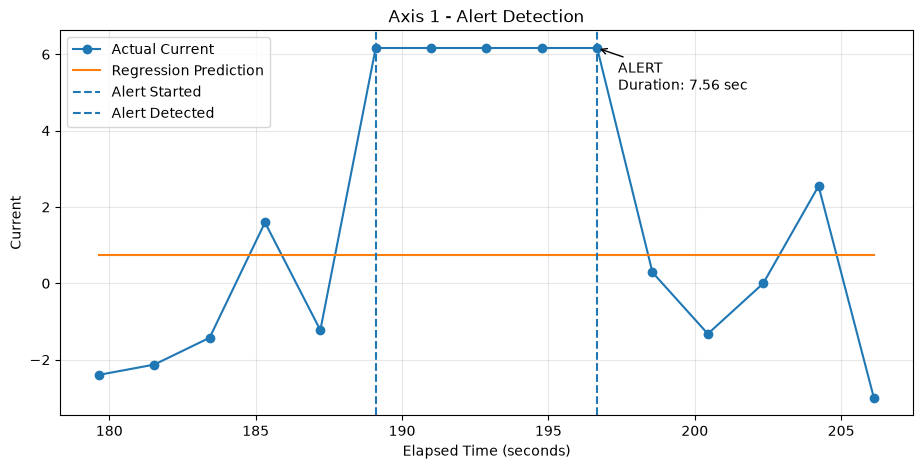

In [41]:
axis = "axis_1"

alert_event = events_df[
    (events_df["axis"] == axis)
    & (events_df["event_type"] == "ALERT")
].iloc[0]

start = alert_event["start_time"] - 10
end = alert_event["detected_time"] + 10

plot_data = test_results[
    (
        test_results["elapsed_seconds"] >= start
    )
    &
    (
        test_results["elapsed_seconds"] <= end
    )
]


plt.figure(figsize=(11, 5))

plt.plot(
    plot_data["elapsed_seconds"],
    plot_data[axis],
    marker="o",
    label="Actual Current"
)

plt.plot(
    plot_data["elapsed_seconds"],
    plot_data[f"{axis}_predicted"],
    label="Regression Prediction"
)

plt.axvline(
    alert_event["start_time"],
    linestyle="--",
    label="Alert Started"
)

plt.axvline(
    alert_event["detected_time"],
    linestyle="--",
    label="Alert Detected"
)

plt.title(
    "Axis 1 - Alert Detection"
)

plt.xlabel(
    "Elapsed Time (seconds)"
)

plt.ylabel(
    "Current"
)

plt.annotate(
    f'ALERT\nDuration: '
    f'{alert_event["duration_seconds"]:.2f} sec',
    xy=(
        alert_event["detected_time"],
        plot_data[axis].max()
    ),
    xytext=(15, -30),
    textcoords="offset points",
    arrowprops={
        "arrowstyle": "->"
    }
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

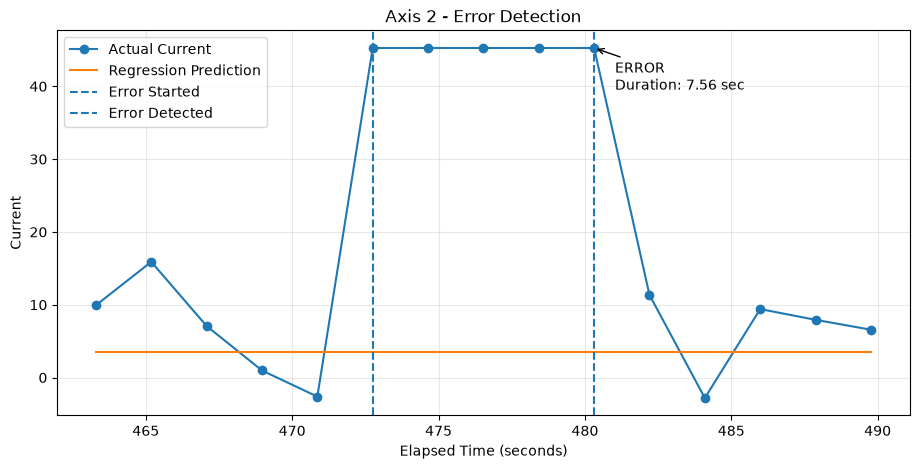

In [42]:
axis = "axis_2"

error_event = events_df[
    (events_df["axis"] == axis)
    & (events_df["event_type"] == "ERROR")
].iloc[0]

start = error_event["start_time"] - 10
end = error_event["detected_time"] + 10

plot_data = test_results[
    (
        test_results["elapsed_seconds"] >= start
    )
    &
    (
        test_results["elapsed_seconds"] <= end
    )
]


plt.figure(figsize=(11, 5))

plt.plot(
    plot_data["elapsed_seconds"],
    plot_data[axis],
    marker="o",
    label="Actual Current"
)

plt.plot(
    plot_data["elapsed_seconds"],
    plot_data[f"{axis}_predicted"],
    label="Regression Prediction"
)

plt.axvline(
    error_event["start_time"],
    linestyle="--",
    label="Error Started"
)

plt.axvline(
    error_event["detected_time"],
    linestyle="--",
    label="Error Detected"
)

plt.title(
    "Axis 2 - Error Detection"
)

plt.xlabel(
    "Elapsed Time (seconds)"
)

plt.ylabel(
    "Current"
)

plt.annotate(
    f'ERROR\nDuration: '
    f'{error_event["duration_seconds"]:.2f} sec',
    xy=(
        error_event["detected_time"],
        plot_data[axis].max()
    ),
    xytext=(15, -30),
    textcoords="offset points",
    arrowprops={
        "arrowstyle": "->"
    }
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

## 26. Detection Summary

The predictive maintenance system detected a total of **6 sustained
abnormal events** in the synthetic testing data.

The two controlled test scenarios were successfully detected:

- **Axis 1 - Alert:** the intentionally injected deviation exceeded
  the MinC threshold for longer than the required duration.
- **Axis 2 - Error:** the intentionally injected deviation exceeded
  the MaxC threshold for longer than the required duration.

Additional Alert events were also detected naturally on Axis 8.
These were not manually injected and demonstrate the sensitivity of
the percentile-based threshold for that axis.

The following summary shows the number of Alert and Error events
generated by the anomaly detection system.

In [43]:
event_summary = (
    events_df["event_type"]
    .value_counts()
    .rename_axis("event_type")
    .reset_index(name="count")
)

display(event_summary)

,event_type,count
0,ALERT,5
1,ERROR,1


In [44]:
display(
    events_df[
        [
            "axis",
            "event_type",
            "start_time",
            "detected_time",
            "duration_seconds",
            "residual"
        ]
    ]
)

,axis,event_type,start_time,detected_time,duration_seconds,residual
0,axis_8,ALERT,128.588,136.152,7.564,0.153688
1,axis_1,ALERT,189.100,196.664,7.564,5.433635
2,axis_8,ALERT,283.650,291.214,7.564,0.263699
3,axis_8,ALERT,425.475,433.039,7.564,0.104502
4,axis_2,ERROR,472.750,480.314,7.564,41.740891
5,axis_8,ALERT,501.115,508.679,7.564,0.317486


## 27. Predictive Maintenance Interpretation

The results demonstrate how regression residuals can be used to
identify unusual robot current behaviour.

The Linear Regression models establish the expected current behaviour
for each robot axis. When the actual current rises above the predicted
value, the residual becomes positive.

A single high residual does not immediately generate an event. The
deviation must remain above the selected threshold continuously for at
least **6 seconds**.

The controlled testing scenarios were successfully detected. Axis 1
generated an Alert after the residual remained above MinC for the
required duration, while Axis 2 generated an Error after the residual
remained above the more severe MaxC threshold.

The detector also identified additional Alert events on Axis 8 that
were not intentionally injected. These results indicate that the
current Axis 8 Alert threshold is relatively sensitive when applied to
synthetic data with realistic variation.

This is useful in a predictive-maintenance context because it shows
that threshold selection requires validation. A threshold that is too
sensitive may produce unnecessary maintenance alerts, while a threshold
that is too high could fail to identify developing equipment problems.

Therefore, both residual magnitude and sustained duration should be
considered when evaluating abnormal equipment behaviour.

## 28. Conclusion

This project extended the original Data Stream Visualization Workshop
with a machine learning-based predictive maintenance pipeline.

Historical robot current data was stored in and retrieved from Neon
PostgreSQL. Separate Linear Regression models were trained for robot
Axes #1–#8 using elapsed time as the independent variable.

Regression residuals were analyzed to establish data-driven Alert and
Error thresholds. The 95th percentile was used for MinC, the 99th
percentile was used for MaxC, and a duration threshold of **6 seconds**
was selected based on the historical sampling interval.

Synthetic testing data was generated using statistical characteristics
learned from the training data. The synthetic dataset was also
standardized using a scaler fitted only on the historical training
data. The existing StreamingSimulator was used to simulate incoming
measurements, and the synthetic records were stored in Neon PostgreSQL.

The anomaly detection system successfully detected both controlled test
scenarios: an Alert on Axis 1 and an Error on Axis 2. Additional natural
Alert events were detected on Axis 8, demonstrating that threshold
sensitivity should be validated before deployment in a production
predictive-maintenance system.

Overall, the project demonstrates a complete workflow from historical
data storage and regression modelling to synthetic streaming, residual
analysis, threshold-based anomaly detection, event logging, and
predictive-maintenance visualization.

In [54]:
print("Final Project Verification")
print("--------------------------")

print(
    "Training records:",
    len(training_df)
)

print(
    "Synthetic testing records:",
    len(synthetic_df)
)

print(
    "Records streamed to Neon:",
    stream_count
)

print(
    "Total detected events:",
    len(events_df)
)

print(
    "Controlled events detected:",
    len(controlled_events)
)

print(
    "Duration threshold:",
    T,
    "seconds"
)

Final Project Verification
--------------------------
Training records: 39672
Synthetic testing records: 500
Records streamed to Neon: 500
Total detected events: 6
Controlled events detected: 2
Duration threshold: 6 seconds
